##Import Modul

**Install library tambahan** yang tidak tersedia secara default di Google Colab:
- `category_encoders`: untuk encoding seperti TargetEncoder dan CountEncoder
- `xgboost`: model gradient boosting berbasis pohon yang cepat dan akurat
- `catboost`: gradient boosting yang dioptimalkan untuk fitur kategorikal

In [1]:
pip install category_encoders

In [2]:
pip install xgboost

In [3]:
pip install catboost

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder
from category_encoders import CountEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

##Data Preparation

In [5]:
plane_df = pd.read_csv('/content/planes.csv')

In [6]:
plane_df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
2,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0
3,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873.0
4,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087.0


In [7]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10660 entries, 0 to 10659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10233 non-null  object 
 1   Date_of_Journey  10338 non-null  object 
 2   Source           10473 non-null  object 
 3   Destination      10313 non-null  object 
 4   Route            10404 non-null  object 
 5   Dep_Time         10400 non-null  object 
 6   Arrival_Time     10466 non-null  object 
 7   Duration         10446 non-null  object 
 8   Total_Stops      10448 non-null  object 
 9   Additional_Info  10071 non-null  object 
 10  Price            10044 non-null  float64
dtypes: float64(1), object(10)
memory usage: 916.2+ KB


##EDA

### 1. Distribusi Target Variable (Price)

**Visualisasi distribusi harga tiket** (`Price`) dalam dua bentuk:
- Kiri: distribusi asli — biasanya skewed ke kanan karena ada tiket yang sangat mahal
- Kanan: distribusi setelah log-transform (`log1p`) — lebih simetris dan cocok untuk modeling

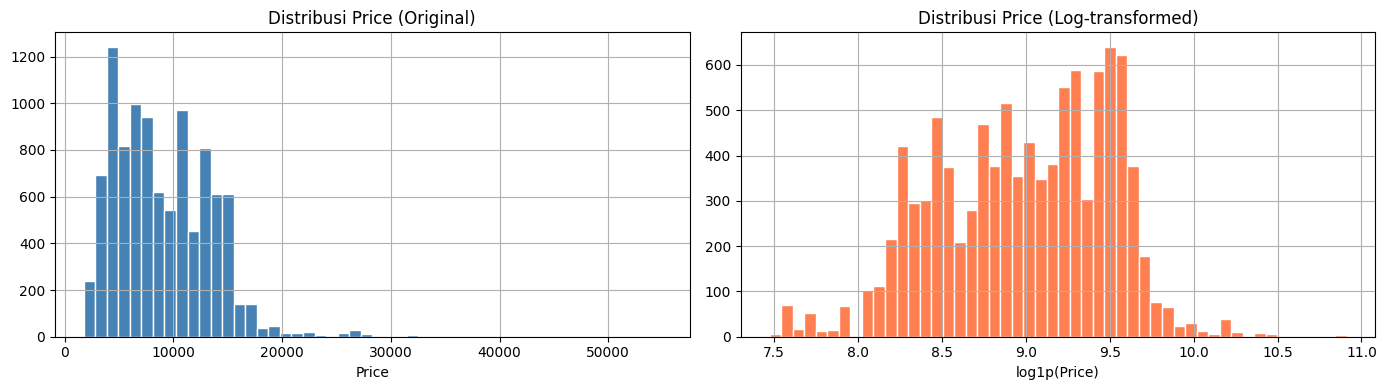

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plane_df['Price'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Price (Original)')
axes[0].set_xlabel('Price')

np.log1p(plane_df['Price']).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribusi Price (Log-transformed)')
axes[1].set_xlabel('log1p(Price)')

plt.tight_layout()
plt.show()

- Kiri (Original): Distribusi harga tiket awal sangat menceng ke kanan (right-skewed) dengan long tail dan menumpuk di kisaran harga rendah. Kondisi ini kurang ideal untuk performa beberapa model machine learning.

- Kanan (Log-transformed): Setelah diterapkan log1p(Price), distribusi data bergeser menjadi jauh lebih simetris dan mendekati distribusi normal. Transformasi ini membantu model dalam mengenali pola data secara lebih stabil.

### 2. Harga Tiket per Maskapai

**Boxplot harga tiket per maskapai**, diurutkan dari median harga tertinggi ke terendah. Berguna untuk melihat maskapai mana yang cenderung punya harga lebih mahal atau lebih murah.

/tmp/ipykernel_22565/3389679335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plane_df, x='Airline', y='Price', order=order, palette='Set2')


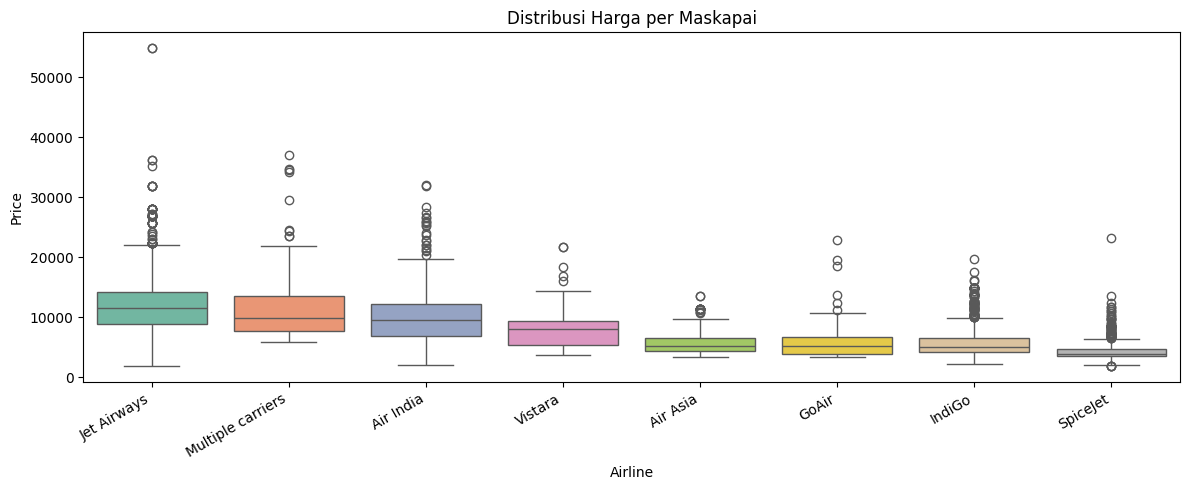

In [9]:
plt.figure(figsize=(12, 5))
order = plane_df.groupby('Airline')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=plane_df, x='Airline', y='Price', order=order, palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.title('Distribusi Harga per Maskapai')
plt.tight_layout()
plt.show()

- Jet Airways, Multiple Carriers, dan Air India merupakan kelompok maskapai dengan rentang harga tiket tertinggi dan memiliki banyak pencilan (outliers) di atas batas atasnya.

- Maskapai bertarif rendah seperti SpiceJet, IndiGo, dan Air Asia memiliki variasi harga yang cenderung rendah, stabil, dan sebaran datanya lebih rapat.

### 3. Harga Tiket vs Jumlah Stops

/tmp/ipykernel_22565/670078493.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plane_df, x='Total_Stops', y='Price', order=order, palette='Blues')


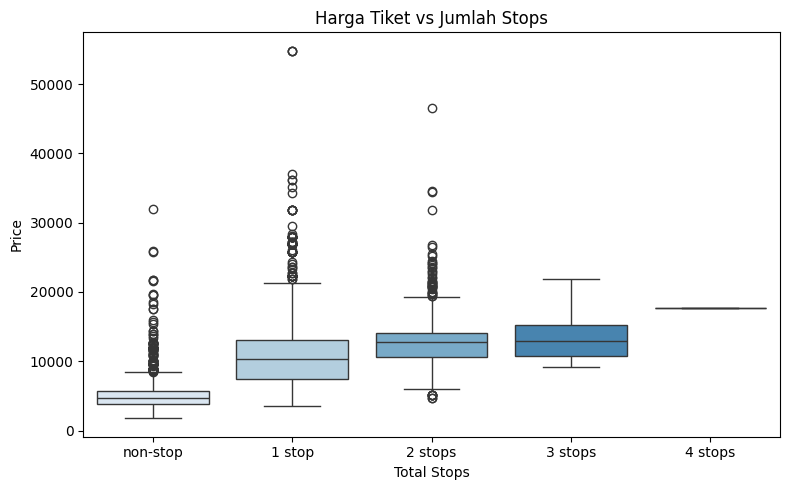

In [10]:
plt.figure(figsize=(8, 5))
order = ['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']
order = [o for o in order if o in plane_df['Total_Stops'].unique()]
sns.boxplot(data=plane_df, x='Total_Stops', y='Price', order=order, palette='Blues')
plt.title('Harga Tiket vs Jumlah Stops')
plt.xlabel('Total Stops')
plt.tight_layout()
plt.show()

- Terdapat tren linear positif yang jelas: semakin banyak jumlah transit (stops), median harga tiket cenderung semakin mahal.

- Penerbangan non-stop memiliki harga paling ekonomis, sementara penerbangan dengan 1 hingga 3 stops mengalami kenaikan harga bertahap. (Catatan: Data untuk 4 stops sangat sedikit/terbatas).

### 4. Harga Tiket per Rute (Source → Destination)

/tmp/ipykernel_22565/3969024547.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plane_df, x='Route_SD', y='Price', order=order, palette='viridis', estimator='median', errorbar=None)


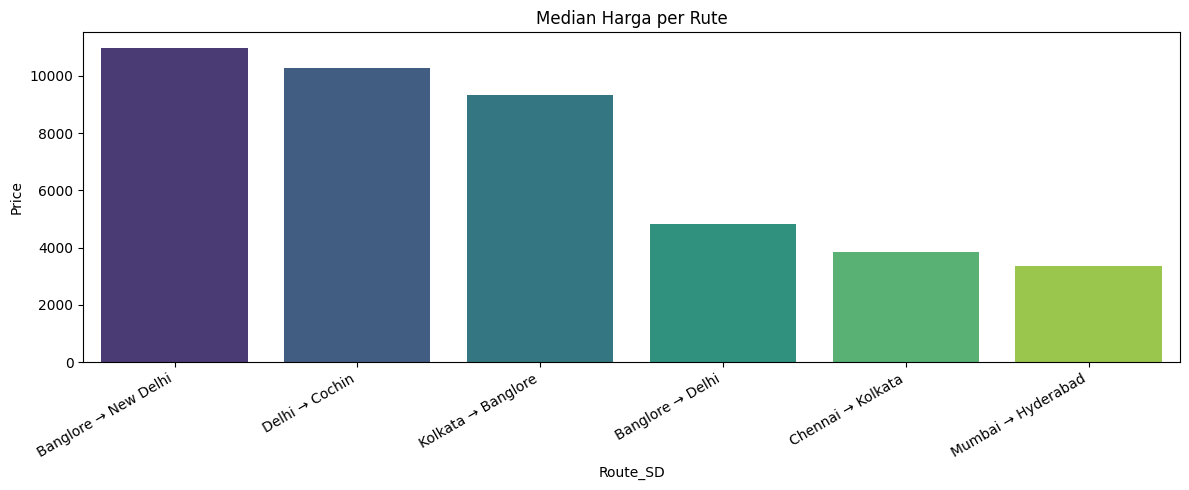

In [11]:
plane_df['Route_SD'] = plane_df['Source'] + ' → ' + plane_df['Destination']
plt.figure(figsize=(12, 5))
order = plane_df.groupby('Route_SD')['Price'].median().sort_values(ascending=False).index
sns.barplot(data=plane_df, x='Route_SD', y='Price', order=order, palette='viridis', estimator='median', errorbar=None)
plt.xticks(rotation=30, ha='right')
plt.title('Median Harga per Rute')
plt.tight_layout()
plt.show()
plane_df.drop('Route_SD', axis=1, inplace=True)

- Rute Banglore $\rightarrow$ New Delhi, Delhi $\rightarrow$ Cochin, dan Kolkata $\rightarrow$ Banglore merupakan rute-rute premium dengan median harga tiket tertinggi (di atas 9.000).

- Sebaliknya, rute pendek atau rute domestik tertentu seperti Mumbai $\rightarrow$ Hyderabad dan Chennai $\rightarrow$ Kolkata menawarkan median harga paling murah (di bawah 4.000).

### 5. Jumlah Penerbangan per Maskapai

/tmp/ipykernel_22565/991057889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=plane_df, x='Airline', order=order, palette='Set3')


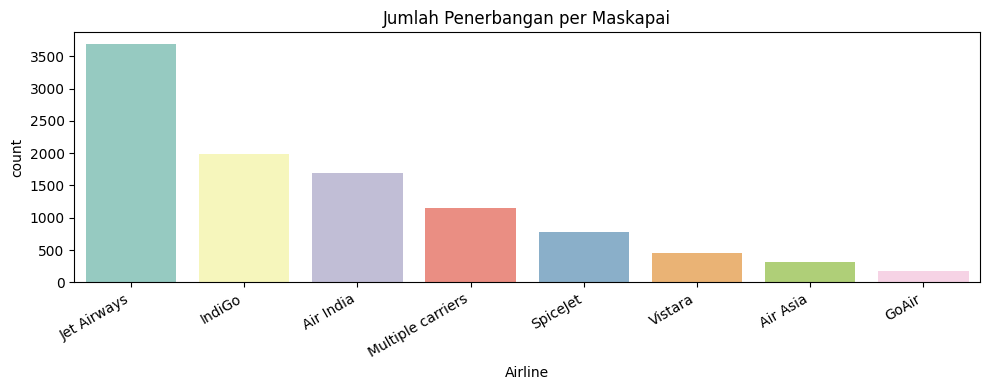

In [12]:
plt.figure(figsize=(10, 4))
order = plane_df['Airline'].value_counts().index
sns.countplot(data=plane_df, x='Airline', order=order, palette='Set3')
plt.xticks(rotation=30, ha='right')
plt.title('Jumlah Penerbangan per Maskapai')
plt.tight_layout()
plt.show()

- Jet Airways mendominasi pasar secara mutlak dengan volume penerbangan terbanyak (di atas 3.500 penerbangan), disusul oleh IndiGo dan Air India.

- Maskapai seperti GoAir dan Air Asia memiliki frekuensi penerbangan paling sedikit di dalam dataset ini, yang menunjukkan ketimpangan distribusi kelas data (data imbalance) pada fitur maskapai.

##Data Cleaning

In [13]:
plane_df.duplicated().sum()

np.int64(134)

**Menghapus baris duplikat** secara in-place agar tidak ada data yang diproses dua kali.

In [14]:
plane_df.drop_duplicates(inplace=True)

In [15]:
plane_df['Route'].value_counts()

,count
Route,
DEL → BOM → COK,2317
BLR → DEL,1493
CCU → BOM → BLR,950
CCU → BLR,704
BOM → HYD,603
...,...
BOM → VNS → DEL → HYD,1
BLR → HBX → BOM → NAG → DEL,1
BLR → BOM → IXC → DEL,1


In [16]:
plane_df['Additional_Info'].value_counts()

,count
Additional_Info,
No info,7761
In-flight meal not included,1848
No check-in baggage included,297
1 Long layover,18
Change airports,7
No Info,2
1 Short layover,1
Business class,1
Red-eye flight,1


In [17]:
plane_df[plane_df.isna().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
18,GoAir,6/03/2019,Delhi,Cochin,DEL → BOM → COK,14:10,19:20,5h 10m,1 stop,NaN,19495.0
35,NaN,18/05/2019,Kolkata,Banglore,CCU → BLR,14:15,16:45,2h 30m,non-stop,No info,6245.0
38,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → HYD → COK,07:05,18:10,11h 5m,1 stop,NaN,9646.0
41,Air Asia,NaN,Banglore,Delhi,BLR → DEL,11:10,13:55,2h 45m,non-stop,No info,3383.0
43,SpiceJet,24/03/2019,Banglore,NaN,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,3527.0
...,...,...,...,...,...,...,...,...,...,...,...
10633,NaN,6/04/2019,Banglore,Delhi,BLR → DEL,07:00,09:40,2h 40m,non-stop,No info,5613.0
10637,Vistara,21/03/2019,Banglore,New Delhi,BLR → DEL,21:10,00:05 19 Mar,2h 55m,non-stop,NaN,4878.0
10648,Air India,6/06/2019,Mumbai,Hyderabad,BOM → HYD,21:05,22:25,1h 20m,non-stop,NaN,3100.0
10653,Multiple carriers,1/05/2019,Delhi,Cochin,DEL → BOM → COK,10:20,19:00,8h 40m,1 stop,No info,NaN


**Mengisi nilai kosong** pada kolom `Additional_Info` dengan string `'No Info'` agar tidak ada NaN.

In [18]:
plane_df['Additional_Info'].fillna('No Info', inplace=True)

/tmp/ipykernel_22565/2619167204.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  plane_df['Additional_Info'].fillna('No Info', inplace=True)


In [19]:
plane_df.isna().sum()

,0
Airline,427
Date_of_Journey,316
Source,187
Destination,347
Route,256
Dep_Time,260
Arrival_Time,194
Duration,214
Total_Stops,212
Additional_Info,0


Memperbaiki nilai durasi yang hilang

**Mengisi nilai `Duration` yang kosong** dengan menghitung selisih antara `Dep_Time` dan `Arrival_Time`. Jika waktu tiba lebih awal dari waktu berangkat, diasumsikan melewati tengah malam sehingga ditambah 1 hari.

In [20]:
mask = plane_df['Duration'].isna()

dep = pd.to_datetime(
    plane_df.loc[mask, 'Dep_Time'].str.extract(r'(\d{2}:\d{2})')[0],
    format='%H:%M',
    errors='coerce'
)

arr = pd.to_datetime(
    plane_df.loc[mask, 'Arrival_Time'].str.extract(r'(\d{2}:\d{2})')[0],
    format='%H:%M',
    errors='coerce'
)

arr = arr.where(arr >= dep, arr + pd.Timedelta(days=1))

duration = arr - dep

plane_df.loc[mask, 'Duration'] = duration.apply(
    lambda x: (
        f"{x.components.hours}h {x.components.minutes}m"
        if pd.notna(x)
        else None
    )
)

In [21]:
plane_df['Duration'].isna().sum()

np.int64(13)

**Menghapus baris** di mana kolom `Price` (target) bernilai NaN — baris tanpa harga tidak bisa digunakan untuk training.

In [22]:
plane_df.dropna(subset=['Price'], inplace=True)

In [23]:
plane_df.isna().sum()

,0
Airline,362
Date_of_Journey,297
Source,155
Destination,304
Route,244
Dep_Time,240
Arrival_Time,185
Duration,13
Total_Stops,144
Additional_Info,0


In [24]:
plane_df[plane_df['Destination'].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
43,SpiceJet,24/03/2019,Banglore,NaN,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,3527.0
87,Jet Airways,24/05/2019,Kolkata,NaN,CCU → DEL → BLR,20:25,14:25 25 May,18h,1 stop,In-flight meal not included,10703.0
131,IndiGo,15/06/2019,Kolkata,NaN,CCU → BLR,20:25,23:10,2h 45m,non-stop,No info,4804.0
175,Vistara,21/05/2019,Kolkata,NaN,CCU → DEL → BLR,17:00,18:50 22 May,25h 50m,1 stop,No info,9345.0
198,GoAir,24/03/2019,Kolkata,NaN,CCU → BOM → BLR,22:25,07:40 25 Mar,9h 15m,1 stop,No Info,10091.0
...,...,...,...,...,...,...,...,...,...,...,...
10494,GoAir,21/06/2019,Banglore,NaN,BLR → DEL,11:40,14:30,2h 50m,non-stop,No info,3398.0
10538,Jet Airways,01/03/2019,Banglore,NaN,BLR → BOM → DEL,14:05,09:00 02 Mar,18h 55m,1 stop,No info,20800.0
10577,IndiGo,3/06/2019,Delhi,NaN,DEL → HYD → COK,14:20,22:30,8h 10m,1 stop,No Info,6938.0
10582,IndiGo,21/03/2019,Banglore,NaN,BLR → DEL,20:00,22:55,2h 55m,non-stop,No info,6144.0


**Menghapus baris** yang masih memiliki NaN di kolom penting: `Route`, `Duration`, atau `Date_of_Journey`.

In [25]:
plane_df.dropna(subset=['Route', 'Duration', 'Date_of_Journey'], inplace=True)

In [26]:
plane_df.isna().sum()

,0
Airline,346
Date_of_Journey,0
Source,146
Destination,285
Route,0
Dep_Time,218
Arrival_Time,169
Duration,0
Total_Stops,134
Additional_Info,0


**Mengisi NaN di kolom `Airline`** dengan string `'Unknown Airline'` agar tidak ada missing value.

In [27]:
plane_df['Airline'] = plane_df['Airline'].fillna('Unknown Airline')

**Mengisi NaN di kolom `Source` dan `Destination`** menggunakan peta kode bandara (`airport_map`). Kode bandara diambil dari kolom `Route` (dipisah berdasarkan ' → ') lalu dipetakan ke nama kota.

In [28]:
airport_map = {
    'DEL': 'Delhi',
    'BLR': 'Banglore',
    'CCU': 'Kolkata',
    'BOM': 'Mumbai',
    'COK': 'Cochin',
    'HYD': 'Hyderabad',
    'MAA': 'Chennai'
}

route_split = plane_df['Route'].str.split(' → ')

plane_df.loc[
    plane_df['Source'].isna(),
    'Source'
] = route_split.str[0].map(airport_map)

plane_df.loc[
    plane_df['Destination'].isna(),
    'Destination'
] = route_split.str[-1].map(airport_map)



**Mengisi NaN di kolom `Total_Stops`** dengan menghitung jumlah stop dari kolom `Route`. Logika: jumlah segmen dalam rute dikurangi 2 (titik awal dan tujuan akhir) = jumlah stop.

In [29]:
def calculate_stops(route):
    if pd.isna(route):
        return 'non-stop'

    stops = len(route.split(' → ')) - 2

    if stops <= 0:
        return 'non-stop'
    elif stops == 1:
        return '1 stop'
    else:
        return f'{stops} stops'

plane_df.loc[
    plane_df['Total_Stops'].isna(),
    'Total_Stops'
] = plane_df.loc[
    plane_df['Total_Stops'].isna(),
    'Route'
].apply(calculate_stops)

**Fungsi `duration_to_minutes`** (versi pertama, untuk data yang masih ada NaN): mengubah string durasi seperti `'2h 30m'` menjadi angka menit (150). Digunakan untuk kalkulasi waktu tiba/berangkat yang hilang.

In [30]:
def duration_to_minutes(duration):
    if pd.isna(duration):
        return np.nan

    h = 0
    m = 0

    if 'h' in duration:
        h = int(duration.split('h')[0].strip())

    if 'm' in duration:
        m = int(duration.split('h')[-1].replace('m', '').strip())

    return h * 60 + m


duration_minutes = plane_df['Duration'].apply(duration_to_minutes)

**Mengisi nilai `Arrival_Time` atau `Dep_Time` yang kosong** dengan cara menghitung mundur/maju dari waktu yang tersedia dan durasi penerbangan.

In [31]:
dep_time = pd.to_datetime(
    plane_df['Dep_Time'].str.extract(r'(\d{2}:\d{2})')[0],
    format='%H:%M',
    errors='coerce'
)

arr_time = pd.to_datetime(
    plane_df['Arrival_Time'].str.extract(r'(\d{2}:\d{2})')[0],
    format='%H:%M',
    errors='coerce'
)


missing_arr = plane_df['Arrival_Time'].isna()

calculated_arr = dep_time + pd.to_timedelta(duration_minutes, unit='m')

plane_df.loc[missing_arr, 'Arrival_Time'] = calculated_arr[
    missing_arr
].dt.strftime('%H:%M')


missing_dep = plane_df['Dep_Time'].isna()

calculated_dep = arr_time - pd.to_timedelta(duration_minutes, unit='m')

plane_df.loc[missing_dep, 'Dep_Time'] = calculated_dep[
    missing_dep
].dt.strftime('%H:%M')


In [32]:
print(plane_df.isna().sum())

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           1
Arrival_Time       1
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64


In [33]:
plane_df.loc[plane_df['Dep_Time'].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
1930,Jet Airways,9/03/2019,Delhi,Cochin,DEL → IXC → BOM → COK,NaN,NaN,14h 40m,2 stops,In-flight meal not included,15129.0


In [34]:
plane_df.loc[plane_df['Arrival_Time'].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
1930,Jet Airways,9/03/2019,Delhi,Cochin,DEL → IXC → BOM → COK,NaN,NaN,14h 40m,2 stops,In-flight meal not included,15129.0


**Menghapus semua baris yang masih memiliki NaN** — tahap pembersihan final.

In [35]:
plane_df.dropna(inplace=True)

##Feature Engineering

In [36]:
plane_df['Route'].unique()

array(['DEL → LKO → BOM → COK', 'CCU → NAG → BLR', 'BLR → NAG → DEL',
       'CCU → BLR', 'BLR → BOM → DEL', 'DEL → BOM → COK',
       'DEL → BLR → COK', 'MAA → CCU', 'CCU → BOM → BLR',
       'DEL → AMD → BOM → COK', 'DEL → PNQ → COK',
       'DEL → CCU → BOM → COK', 'BLR → COK → DEL', 'BLR → DEL',
       'DEL → IDR → BOM → COK', 'DEL → LKO → COK',
       'CCU → GAU → DEL → BLR', 'DEL → NAG → BOM → COK',
       'CCU → MAA → BLR', 'DEL → HYD → COK', 'CCU → HYD → BLR',
       'DEL → COK', 'CCU → DEL → BLR', 'BLR → BOM → AMD → DEL',
       'BOM → DEL → HYD', 'DEL → MAA → COK', 'BOM → HYD',
       'DEL → BHO → BOM → COK', 'DEL → JAI → BOM → COK',
       'DEL → JDH → BOM → COK', 'CCU → BBI → BOM → BLR',
       'BLR → MAA → DEL', 'DEL → ATQ → BOM → COK',
       'DEL → BDQ → BOM → COK', 'CCU → JAI → BOM → BLR',
       'CCU → BBI → BLR', 'BLR → HYD → DEL', 'DEL → TRV → COK',
       'CCU → IXR → DEL → BLR', 'CCU → IXB → BLR',
       'BLR → BOM → JDH → DEL', 'DEL → UDR → BOM → COK',
       'DEL

In [37]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9363 entries, 0 to 10659
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          9363 non-null   object 
 1   Date_of_Journey  9363 non-null   object 
 2   Source           9363 non-null   object 
 3   Destination      9363 non-null   object 
 4   Route            9363 non-null   object 
 5   Dep_Time         9363 non-null   object 
 6   Arrival_Time     9363 non-null   object 
 7   Duration         9363 non-null   object 
 8   Total_Stops      9363 non-null   object 
 9   Additional_Info  9363 non-null   object 
 10  Price            9363 non-null   float64
dtypes: float64(1), object(10)
memory usage: 877.8+ KB


**Memecah kolom `Route`** menjadi beberapa kolom terpisah: `Route 1` s.d. `Route 6`, berdasarkan pemisah ' → '. Setiap kolom merepresentasikan satu titik singgah dalam rute.

In [38]:
plane_df['Route 1'] = plane_df['Route'].str.split(' → ').str[0]
plane_df['Route 2'] = plane_df['Route'].str.split(' → ').str[1]
plane_df['Route 3'] = plane_df['Route'].str.split(' → ').str[2]
plane_df['Route 4'] = plane_df['Route'].str.split(' → ').str[3]
plane_df['Route 5'] = plane_df['Route'].str.split(' → ').str[4]
plane_df['Route 6'] = plane_df['Route'].str.split(' → ').str[5]

In [39]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9363 entries, 0 to 10659
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          9363 non-null   object 
 1   Date_of_Journey  9363 non-null   object 
 2   Source           9363 non-null   object 
 3   Destination      9363 non-null   object 
 4   Route            9363 non-null   object 
 5   Dep_Time         9363 non-null   object 
 6   Arrival_Time     9363 non-null   object 
 7   Duration         9363 non-null   object 
 8   Total_Stops      9363 non-null   object 
 9   Additional_Info  9363 non-null   object 
 10  Price            9363 non-null   float64
 11  Route 1          9363 non-null   object 
 12  Route 2          9363 non-null   object 
 13  Route 3          6270 non-null   object 
 14  Route 4          1285 non-null   object 
 15  Route 5          37 non-null     object 
 16  Route 6          1 non-null      object 
dtypes: float64(1), obj

**Menghapus kolom `Route` asli** karena sudah dipecah menjadi `Route 1`–`Route 6`.

In [40]:
plane_df.drop("Route", axis=1,inplace=True)

In [41]:
plane_df.head(5)

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Route 1,Route 2,Route 3,Route 4,Route 5,Route 6
0,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,DEL,LKO,BOM,COK,NaN,NaN
1,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218.0,CCU,NAG,BLR,NaN,NaN,NaN
2,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302.0,BLR,NAG,DEL,NaN,NaN,NaN
3,SpiceJet,24/06/2019,Kolkata,Banglore,09:00,11:25,2h 25m,non-stop,No info,3873.0,CCU,BLR,NaN,NaN,NaN,NaN
4,Jet Airways,12/03/2019,Banglore,New Delhi,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087.0,BLR,BOM,DEL,NaN,NaN,NaN


**Mengonversi kolom `Date_of_Journey`** dari string ke tipe datetime agar bisa diekstrak fitur tanggal (hari, bulan, hari dalam seminggu).

In [42]:
plane_df['Date_of_Journey'] = pd.to_datetime(plane_df['Date_of_Journey'], format='%d/%m/%Y')

**Mengisi NaN di kolom `Route 3`–`Route 6`** dengan string `"Don't Have"`, karena penerbangan dengan stop sedikit tidak menggunakan semua kolom route.

In [43]:
plane_df[['Route 3', 'Route 4', 'Route 5', 'Route 6']] = (
    plane_df[['Route 3', 'Route 4', 'Route 5', 'Route 6']]
    .fillna("Don't Have")
)

In [44]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9363 entries, 0 to 10659
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          9363 non-null   object        
 1   Date_of_Journey  9363 non-null   datetime64[ns]
 2   Source           9363 non-null   object        
 3   Destination      9363 non-null   object        
 4   Dep_Time         9363 non-null   object        
 5   Arrival_Time     9363 non-null   object        
 6   Duration         9363 non-null   object        
 7   Total_Stops      9363 non-null   object        
 8   Additional_Info  9363 non-null   object        
 9   Price            9363 non-null   float64       
 10  Route 1          9363 non-null   object        
 11  Route 2          9363 non-null   object        
 12  Route 3          9363 non-null   object        
 13  Route 4          9363 non-null   object        
 14  Route 5          9363 non-null   object     

**Mengecek duplikat** setelah semua transformasi, duplikat bisa muncul kembali setelah operasi join/split.

In [45]:
plane_df.duplicated().sum()

np.int64(18)

**Menghapus duplikat** yang muncul setelah transformasi.

In [46]:
plane_df.drop_duplicates(inplace=True)

In [47]:
plane_df.duplicated().sum()

np.int64(0)

In [48]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9345 entries, 0 to 10659
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          9345 non-null   object        
 1   Date_of_Journey  9345 non-null   datetime64[ns]
 2   Source           9345 non-null   object        
 3   Destination      9345 non-null   object        
 4   Dep_Time         9345 non-null   object        
 5   Arrival_Time     9345 non-null   object        
 6   Duration         9345 non-null   object        
 7   Total_Stops      9345 non-null   object        
 8   Additional_Info  9345 non-null   object        
 9   Price            9345 non-null   float64       
 10  Route 1          9345 non-null   object        
 11  Route 2          9345 non-null   object        
 12  Route 3          9345 non-null   object        
 13  Route 4          9345 non-null   object        
 14  Route 5          9345 non-null   object     

In [49]:
numerical_columns = plane_df.select_dtypes(include=['int64', 'float']).columns

**Deteksi outlier** menggunakan metode IQR (Interquartile Range):
- `Q1` = kuartil 25%, `Q3` = kuartil 75%
- `IQR = Q3 - Q1`
- Data dianggap outlier jika berada di luar rentang `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`
- Jumlah outlier per kolom dicetak untuk pertimbangan lebih lanjut

In [50]:
for col in numerical_columns:
    Q1 = plane_df[col].quantile(0.25)
    Q3 = plane_df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = plane_df[(plane_df[col] < Q1 - 1.5*IQR) | (plane_df[col] > Q3 + 1.5*IQR)]

    print(f"{col} jumlah outlier: {len(outliers)}")

Price jumlah outlier: 79


Terdapat 79 outlier pada fitur Price berdasarkan metode IQR. Namun, outlier tidak dihapus karena harga tiket dipengaruhi oleh faktor maskapai dan layanan penerbangan sehingga masih valid secara bisnis. Untuk mengurangi skewness, dilakukan transformasi log menggunakan np.log1p() agar distribusi data lebih stabil dan optimal untuk pemodelan.

In [51]:
plane_df.head(5)

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Route 1,Route 2,Route 3,Route 4,Route 5,Route 6
0,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,DEL,LKO,BOM,COK,Don't Have,Don't Have
1,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,No info,6218.0,CCU,NAG,BLR,Don't Have,Don't Have,Don't Have
2,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302.0,BLR,NAG,DEL,Don't Have,Don't Have,Don't Have
3,SpiceJet,2019-06-24,Kolkata,Banglore,09:00,11:25,2h 25m,non-stop,No info,3873.0,CCU,BLR,Don't Have,Don't Have,Don't Have,Don't Have
4,Jet Airways,2019-03-12,Banglore,New Delhi,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087.0,BLR,BOM,DEL,Don't Have,Don't Have,Don't Have


In [52]:
plane_df['Arrival_Hour'] = pd.to_datetime(
    plane_df['Arrival_Time'].str[:5]
).dt.hour

plane_df['Arrival_Minute'] = pd.to_datetime(
    plane_df['Arrival_Time'].str[:5]
).dt.minute

/tmp/ipykernel_22565/4284153581.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plane_df['Arrival_Hour'] = pd.to_datetime(
/tmp/ipykernel_22565/4284153581.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plane_df['Arrival_Minute'] = pd.to_datetime(


**Ekstrak jam dan menit dari `Arrival_Time`** menjadi kolom `Arrival_Hour` dan `Arrival_Minute` agar lebih mudah diproses model numerik.

In [53]:
plane_df['Arrival_Next_Day'] = (
    plane_df['Arrival_Time'].str.contains(' ')
).astype(int)

**Mendeteksi penerbangan yang tiba di hari berikutnya** berdasarkan keberadaan spasi dalam string `Arrival_Time`. Hasilnya disimpan ke kolom `Arrival_Next_Day` (0 = hari sama, 1 = hari berikutnya).

In [54]:
def duration_to_minutes(duration):
    hours = 0
    minutes = 0

    if 'h' in duration:
        hours = int(duration.split('h')[0])

    if 'm' in duration:
        minutes = int(duration.split('m')[0].split()[-1])

    return hours * 60 + minutes

plane_df['Duration_Minutes'] = (
    plane_df['Duration']
    .apply(duration_to_minutes)
)

**Fungsi `duration_to_minutes`** (versi final, untuk data yang sudah bersih): mengonversi string durasi seperti `'2h 30m'` ke total menit. Hasilnya disimpan di kolom `Duration_Minutes`.

In [55]:
plane_df['Dep_Hour'] = pd.to_datetime(
    plane_df['Dep_Time']
).dt.hour

plane_df['Dep_Minute'] = pd.to_datetime(
    plane_df['Dep_Time']
).dt.minute

/tmp/ipykernel_22565/291485624.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plane_df['Dep_Hour'] = pd.to_datetime(
/tmp/ipykernel_22565/291485624.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  plane_df['Dep_Minute'] = pd.to_datetime(


**Ekstrak jam dan menit dari `Dep_Time`** menjadi kolom `Dep_Hour` dan `Dep_Minute` sebagai fitur numerik untuk model.

In [56]:
def time_period(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

plane_df['Dep_Period'] = (
    plane_df['Dep_Hour']
    .apply(time_period)
)

**Membuat fitur `Dep_Period`** yang mengkategorikan waktu keberangkatan ke dalam 4 periode: Night (00–05), Morning (06–11), Afternoon (12–17), Evening (18–23).

**Menghapus kolom asli** `Dep_Time`, `Arrival_Time`, dan `Duration` karena sudah dikonversi ke fitur-fitur yang lebih informatif.

In [57]:
plane_df.drop([
    'Dep_Time',
    'Arrival_Time',
    'Duration'
], axis=1, inplace=True)

In [58]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9345 entries, 0 to 10659
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Airline           9345 non-null   object        
 1   Date_of_Journey   9345 non-null   datetime64[ns]
 2   Source            9345 non-null   object        
 3   Destination       9345 non-null   object        
 4   Total_Stops       9345 non-null   object        
 5   Additional_Info   9345 non-null   object        
 6   Price             9345 non-null   float64       
 7   Route 1           9345 non-null   object        
 8   Route 2           9345 non-null   object        
 9   Route 3           9345 non-null   object        
 10  Route 4           9345 non-null   object        
 11  Route 5           9345 non-null   object        
 12  Route 6           9345 non-null   object        
 13  Arrival_Hour      9345 non-null   int32         
 14  Arrival_Minute    9345 non-n

**Encoding kolom `Total_Stops`** dari teks menjadi angka ordinal: `non-stop` → 0, `1 stop` → 1, `2 stops` → 2, dst. Ini karena stops bersifat ordinal (ada urutan nilainya).

In [59]:
plane_df['Total_Stops'] = plane_df['Total_Stops'].map({'1 stop':1,'non-stop':0,'2 stops':2,'3 stops':3, '4 stops': 4})

In [60]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9345 entries, 0 to 10659
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Airline           9345 non-null   object        
 1   Date_of_Journey   9345 non-null   datetime64[ns]
 2   Source            9345 non-null   object        
 3   Destination       9345 non-null   object        
 4   Total_Stops       9345 non-null   int64         
 5   Additional_Info   9345 non-null   object        
 6   Price             9345 non-null   float64       
 7   Route 1           9345 non-null   object        
 8   Route 2           9345 non-null   object        
 9   Route 3           9345 non-null   object        
 10  Route 4           9345 non-null   object        
 11  Route 5           9345 non-null   object        
 12  Route 6           9345 non-null   object        
 13  Arrival_Hour      9345 non-null   int32         
 14  Arrival_Minute    9345 non-n

## Split Data & Encoding

**Memisahkan fitur (`X`) dan target (`y`)**, lalu split menjadi train dan test (80:20).
- Target `y` dilog-transform dengan `log1p` untuk menstabilkan distribusi harga dan meningkatkan performa model regresi.

In [61]:
X = plane_df.drop('Price', axis=1)
y = np.log1p(plane_df['Price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**Target Encoding untuk kolom `Airline`**: menggantikan nama maskapai dengan rata-rata nilai target (`Price` log) per maskapai. Encoder di-fit hanya pada data train, lalu diterapkan ke test untuk menghindari data leakage.

In [62]:
te = TargetEncoder()
X_train['Airline'] = te.fit_transform(
    X_train['Airline'],
    y_train
)
X_test['Airline'] = te.transform(X_test['Airline'])

**Label Encoding untuk kolom kategorikal nominal** (`Source`, `Destination`, `Additional_Info`, `Dep_Period`): mengubah teks menjadi integer. Setiap encoder disimpan di dictionary `le_encoders` untuk digunakan ulang pada test set.

In [63]:
cols = ['Source', 'Destination', 'Additional_Info', 'Dep_Period']

le_encoders = {}

for col in cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    le_encoders[col] = le

**Count Encoding untuk kolom route** (`Route 1`–`Route 6`): menggantikan setiap nilai dengan frekuensi kemunculannya di data train. Cocok untuk fitur kategorikal dengan banyak nilai unik.

In [64]:
cols = ['Route 1', 'Route 2', 'Route 3', 'Route 4', 'Route 5', 'Route 6']

ce_encoders = {}

for col in cols:
    ce = CountEncoder()
    X_train[col] = ce.fit_transform(X_train[col])
    X_test[col] = ce.transform(X_test[col])
    ce_encoders[col] = ce

In [65]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7476 entries, 3209 to 8258
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Airline           7476 non-null   float64       
 1   Date_of_Journey   7476 non-null   datetime64[ns]
 2   Source            7476 non-null   int64         
 3   Destination       7476 non-null   int64         
 4   Total_Stops       7476 non-null   int64         
 5   Additional_Info   7476 non-null   int64         
 6   Route 1           7476 non-null   int64         
 7   Route 2           7476 non-null   int64         
 8   Route 3           7476 non-null   int64         
 9   Route 4           7476 non-null   int64         
 10  Route 5           7476 non-null   int64         
 11  Route 6           7476 non-null   int64         
 12  Arrival_Hour      7476 non-null   int32         
 13  Arrival_Minute    7476 non-null   int32         
 14  Arrival_Next_Day  7476 non

**Ekstrak fitur waktu dari `Date_of_Journey`**: hari, bulan, dan hari dalam seminggu (weekday). Fitur ini lebih informatif daripada tanggal mentah untuk model.

In [66]:
X_train['Journey_Day'] = X_train['Date_of_Journey'].dt.day
X_train['Journey_Month'] = X_train['Date_of_Journey'].dt.month
X_train['Journey_Weekday'] = X_train['Date_of_Journey'].dt.weekday

X_test['Journey_Day'] = X_test['Date_of_Journey'].dt.day
X_test['Journey_Month'] = X_test['Date_of_Journey'].dt.month
X_test['Journey_Weekday'] = X_test['Date_of_Journey'].dt.weekday

In [67]:
X_train.drop('Date_of_Journey', axis=1, inplace=True)
X_test.drop('Date_of_Journey', axis=1, inplace=True)

##Modelling

In [68]:
rf_model = RandomForestRegressor(
    random_state=123,
    n_jobs=-1
)

param_grid_fast = {
    "n_estimators": [200, 300],
    "max_depth": [6, 8, None],
    "max_features": ["sqrt"]
}

CV_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_fast,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

CV_rf.fit(X_train, y_train)
best_rf_model = CV_rf.best_estimator_

print("Best Parameters:", CV_rf.best_params_)
print("Best CV RMSE (log scale):", abs(CV_rf.best_score_))

y_pred_log = best_rf_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae  = mean_absolute_error(y_test_actual, y_pred)
mse  = mean_squared_error(y_test_actual, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test_actual, y_pred)

print("\n" + "="*80)
print("SUMMARY METRICS (RANDOM FOREST REGRESSOR)")
print("="*80)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV RMSE (log scale): 0.15651249186833008

SUMMARY METRICS (RANDOM FOREST REGRESSOR)
MAE  : 822.1092
MSE  : 2514752.0975
RMSE : 1585.7970
R²   : 0.8737


In [69]:
xgb_model = XGBRegressor(
    random_state=123,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

CV_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

CV_xgb.fit(X_train, y_train)
best_xgb_model = CV_xgb.best_estimator_

print("Best Parameters:", CV_xgb.best_params_)
print("Best CV RMSE (log scale):", abs(CV_xgb.best_score_))

y_pred_log = best_xgb_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae  = mean_absolute_error(y_test_actual, y_pred)
mse  = mean_squared_error(y_test_actual, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test_actual, y_pred)

print("\n" + "="*80)
print("SUMMARY METRICS (XGBOOST REGRESSOR)")
print("="*80)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE (log scale): 0.1340602029392994

SUMMARY METRICS (XGBOOST REGRESSOR)
MAE  : 680.2949
MSE  : 2002606.2752
RMSE : 1415.1347
R²   : 0.8994


In [70]:
cat_model = CatBoostRegressor(
    random_state=123,
    verbose=0
)

param_grid_cat = {
    "iterations": [200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

CV_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid_cat,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

CV_cat.fit(X_train, y_train)
best_cat_model = CV_cat.best_estimator_

print("Best Parameters:", CV_cat.best_params_)
print("Best CV RMSE (log scale):", abs(CV_cat.best_score_))

y_pred_log = best_cat_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

mae  = mean_absolute_error(y_test_actual, y_pred)
mse  = mean_squared_error(y_test_actual, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test_actual, y_pred)

print("\n" + "="*80)
print("SUMMARY METRICS (CATBOOST REGRESSOR)")
print("="*80)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1, 'subsample': 0.8}
Best CV RMSE (log scale): 0.13920713319801858

SUMMARY METRICS (CATBOOST REGRESSOR)
MAE  : 783.0884
MSE  : 2202920.4607
RMSE : 1484.2239
R²   : 0.8893


##Evaluation

                  MAE     RMSE    R²
Random Forest  822.11  1585.80  0.87
XGBoost        680.29  1415.13  0.90
CatBoost       783.09  1484.22  0.89


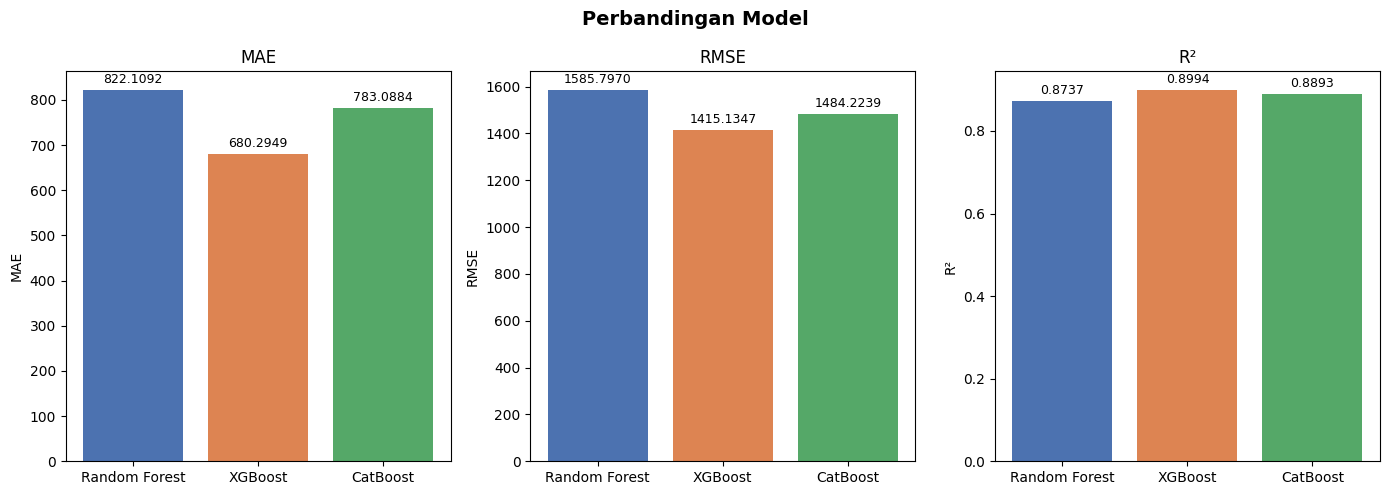

In [71]:
results = {}

for name, model in [
    ("Random Forest", best_rf_model),
    ("XGBoost",       best_xgb_model),
    ("CatBoost",      best_cat_model)
]:
    y_pred = np.expm1(model.predict(X_test))
    results[name] = {
        "MAE":  mean_absolute_error(y_test_actual, y_pred),
        "RMSE": mean_squared_error(y_test_actual, y_pred) ** 0.5,
        "R²":   r2_score(y_test_actual, y_pred)
    }

df_results = pd.DataFrame(results).T
print(df_results.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Perbandingan Model", fontsize=14, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    bars = ax.bar(df_results.index, df_results[metric], color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ax.get_ylim()[1] * 0.01,
            f"{val:.4f}",
            ha="center", va="bottom", fontsize=9
        )

plt.tight_layout()
plt.show()

- Model Terbaik: XGBoost menunjukkan performa paling unggul di antara ketiga model. Hal ini dibuktikan dengan nilai MAE terkecil (680.29) dan RMSE terkecil (1415.13), yang berarti tingkat kesalahan prediksinya paling rendah. Selain itu, nilai $R^2$ sebesar 0.8994 menunjukkan bahwa model ini mampu menjelaskan sekitar 89.9% varians pada data target.
- Model Kompetitor Kedua: CatBoost berada di posisi kedua dengan performa yang cukup bersaing dengan XGBoost ($R^2$ = 0.8893).
- Model Terendah: Random Forest memiliki tingkat error tertinggi (MAE dan RMSE terbesar) serta nilai $R^2$ terendah (0.8737) dibandingkan dengan dua model berbasis gradient boosting lainnya.

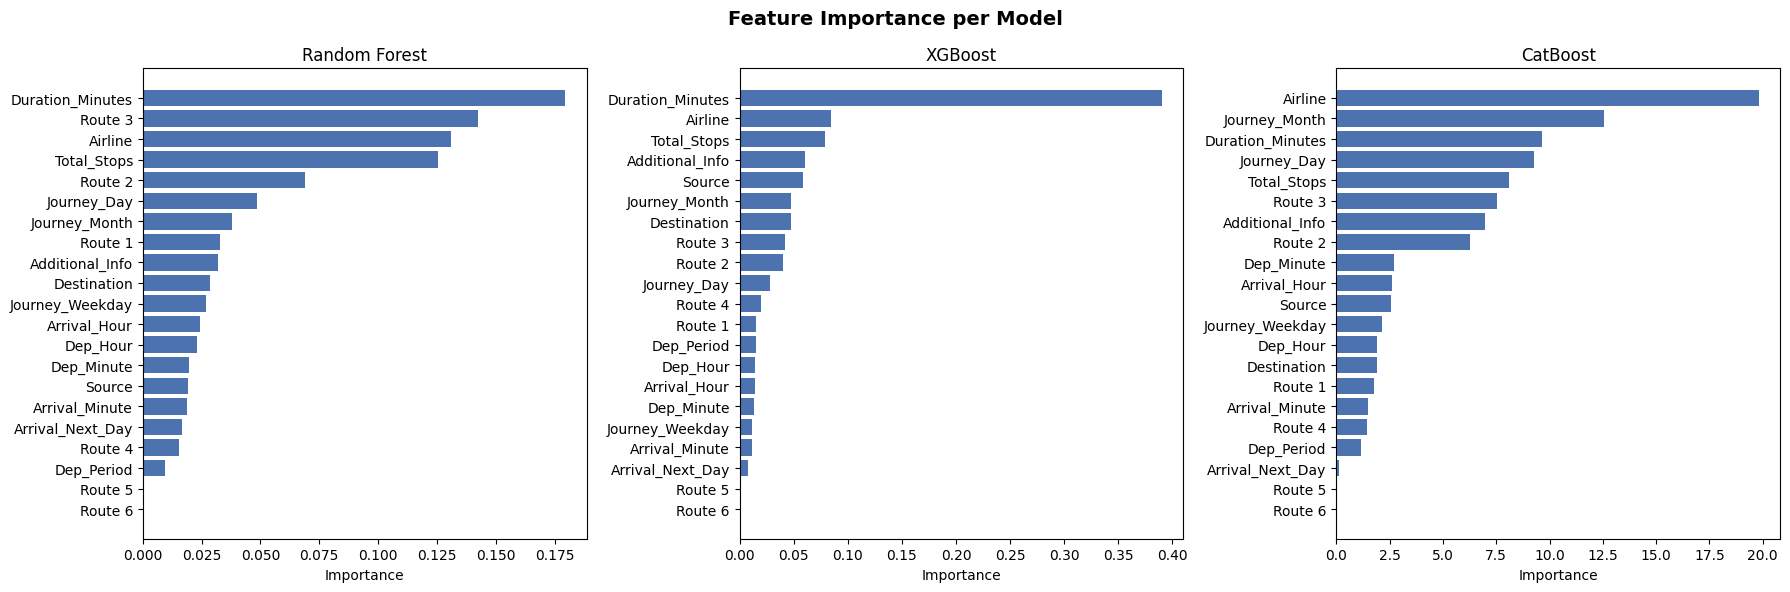

In [72]:
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Feature Importance per Model", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, [
    ("Random Forest", best_rf_model),
    ("XGBoost",       best_xgb_model),
    ("CatBoost",      best_cat_model)
]):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=True)

    ax.barh(fi_df["Feature"], fi_df["Importance"], color="#4C72B0")
    ax.set_title(name)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

- Dominasi Durasi Perjalanan: Fitur Duration_Minutes menjadi faktor paling krusial bagi Random Forest dan XGBoost (bahkan mendominasi sangat tinggi di XGBoost). Di CatBoost, fitur ini tetap berada di posisi 3 besar.

- Pengaruh Maskapai & Rute: Fitur Airline memiliki pengaruh yang sangat signifikan di semua model, terutama pada CatBoost di mana fitur ini menempati posisi pertama. Selain itu, informasi rute seperti Route 3 dan jumlah transit (Total_Stops) juga konsisten berada di papan atas.

- Fitur dengan Kontribusi Minim: Fitur spesifik seperti Route 5 dan Route 6 memiliki nilai importance mendekati nol di ketiga model, menandakan fitur ini bisa dipertimbangkan untuk dihapus pada tahap penyederhanaan model berikutnya.

##Kesimpulan

 Kesimpulan utama untuk proyek prediksi harga tiket pesawat ini:
 - Durasi Perjalanan (Duration_Minutes). Merupakan faktor paling krusial dan dominan yang menentukan harga tiket. Semakin lama durasi penerbangan, harga tiket cenderung meningkat secara signifikan, yang juga berkorelasi erat dengan jumlah transit (Total_Stops).

 - Karakteristik & Dominasi Maskapai (Airline). Jenis maskapai memberikan pengaruh besar terhadap variasi harga. Maskapai premium seperti Jet Airways tidak hanya mendominasi volume penerbangan di dalam dataset, tetapi juga memiliki rata-rata harga tiket tertinggi dibandingkan maskapai Low-Cost Carrier (LCC) seperti SpiceJet atau IndiGo.

 - Dinamika Rute Perjalanan (Route). Lokasi asal dan tujuan menentukan kelas harga tiket. Rute-rute yang menghubungkan kota besar seperti Banglore $\rightarrow$ New Delhi dan Delhi $\rightarrow$ Cochin merupakan rute premium dengan median harga tertinggi, jauh melampaui rute pendek seperti Mumbai $\rightarrow$ Hyderabad.

 Rekomendasi Model: Untuk kebutuhan prediksi atau integrasi ke sistem produksi, model XGBoost adalah pilihan terbaik karena menghasilkan error terendah (MAE: 680.29, RMSE: 1415.13) dan mampu menjelaskan varians data dengan sangat baik ($R^2$: 89.94%) setelah target harga ditransformasikan menggunakan pendekatan logaritma (log1p).